In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

In [2]:
kp = pd.read_csv("../../data/kpneumo/kpneumoniae_data_2023.tsv", sep="\t")
pa = pd.read_csv("../../data/paeruginosa/paeruginosa_data_2023.tsv", sep="\t")
ec = pd.read_csv("../../data/ecoli/ecoli_data_2023.tsv", sep="\t")

df = pd.read_csv("../../data/germany_combined_data_counts.tsv", sep="\t")

In [3]:
te_kp = pd.read_csv("../../data/kpneumo/te_merged.tsv", sep="\t")
te_ec = pd.read_csv("../../data/ecoli/te_merged.tsv", sep="\t")
te_pa = pd.read_csv("../../data/paeruginosa/te_merged.tsv", sep="\t")

<ipython-input-3-6d72a052c167>:1: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  te_kp = pd.read_csv("../../data/kpneumo/te_merged.tsv", sep="\t")
<ipython-input-3-6d72a052c167>:2: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  te_ec = pd.read_csv("../../data/ecoli/te_merged.tsv", sep="\t")
<ipython-input-3-6d72a052c167>:3: DtypeWarning: Columns (2,3,4,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  te_pa = pd.read_csv("../../data/paeruginosa/te_merged.tsv", sep="\t")


In [4]:
result = pd.concat([kp, pa, ec], axis=0, ignore_index=True)

In [5]:
dfs = [result, ec, kp, pa]

In [6]:
for i, df in enumerate(dfs):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce').dt.strftime('%Y-%m-%d')
    df.drop_duplicates(subset='sampleid', keep='first', inplace=True)
    df.loc[df['collection'].isin(['MHH', 'CPH']), 'Consent'] = df['Consent'].fillna('hospital')
    df.loc[df['collection'].isin(['MHH', 'CPH']), 'isolation_source_categ'] = df['isolation_source_categ'].fillna('human')
    df.loc[df['collection'] == 'SRA', 'Consent'] = df['Consent'].fillna('public')
    df.loc[df['collection'] == 'MHH', 'hospital_loc'] = df['hospital_loc'].fillna('Germany')
    df.loc[df['collection'] == 'CPH', 'hospital_loc'] = df['hospital_loc'].fillna('Denmark')

In [7]:
kp_h = kp[kp.Consent != "public"]
ec_h = ec[ec.Consent != "public"]
pa_h = pa[pa.Consent != "public"]

In [8]:
result_h = result[result.Consent == "hospital"]

In [9]:
def plot_sample_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M')

    # Count samples per month and collection
    sample_counts = df.groupby(['year_month', 'collection']).size().unstack(fill_value=0)

    # Define colors
    colors = {'MHH': 'orange', 'CPH': '#4b006e', 'SRA': '#008080'}  # Teal for SRA

    # Plot stacked bar chart with custom bar width
    ax = sample_counts.plot(kind='bar', stacked=True, figsize=(12, 4), width=0.8, color=[colors.get(col, 'gray') for col in sample_counts.columns])

    # Adjust x-axis ticks to show every 6 months
    ax.set_xticks(range(0, len(sample_counts.index), 6))
    ax.set_xticklabels(sample_counts.index.astype(str)[::6], rotation=45)

    plt.xlabel("Sampling Month")
    plt.ylabel("Sample Count")
    plt.title("Stacked Frequency of Samples Over Time (Per Month)")
    plt.legend(title="Collection", facecolor="white")
    plt.show()

In [10]:
# drop random rows
result_h = result_h[result_h.collection != "SRA"]
ec_h = ec_h[ec_h.collection != "SRA"]
kp_h = kp_h[kp_h.collection != "SRA"]
pa_h = pa_h[pa_h.collection != "SRA"]

In [11]:
def plot_total_species_counts(df, where=""):
    # Define color mapping
    color_map = {
        "Escherichia coli": "#448ee4",
        "Klebsiella pneumoniae": "#ffa756",
        "Pseudomonas aeruginosa": "#7e1e9c"
    }

    # Prepare species label mapping with line breaks
    label_map = {
        "Escherichia coli": r"$\it{E.}\ coli$",
        "Klebsiella pneumoniae": r"$\it{K.}\ pneumoniae$",
        "Pseudomonas aeruginosa": r"$\it{P.}\ aeruginosa$"
    }

    # Count samples per species
    species_counts = df['species'].value_counts().loc[color_map.keys()]
    species_counts = species_counts[species_counts > 0]

    # Replace index with wrapped labels
    species_counts.index = [label_map[sp] for sp in species_counts.index]

    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(
        y=species_counts.index,
        x=species_counts.values,
        palette=[color_map[sp] for sp in label_map.keys() if sp in df['species'].unique()],
        ax=ax
    )

    max_count = species_counts.max()
    ax.set_xticks(np.arange(0, max_count + 10000, 10000))

    # Show all spines
    for spine in ax.spines.values():
        spine.set_visible(True)

    
    sns.despine(left=False, bottom=False, right=True, top=True)

    ax.set_xlabel("", fontsize=16)
    ax.set_ylabel("", fontsize=16)
    ax.tick_params(labelsize=16)
    plt.title("", fontsize=18)

    # Empty legend with white background
    ax.legend([], frameon=True, facecolor="white")
    
    plt.tight_layout()
    
    plt.savefig(f'../../out/figures/species_counts_{where}.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/species_counts_{where}.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

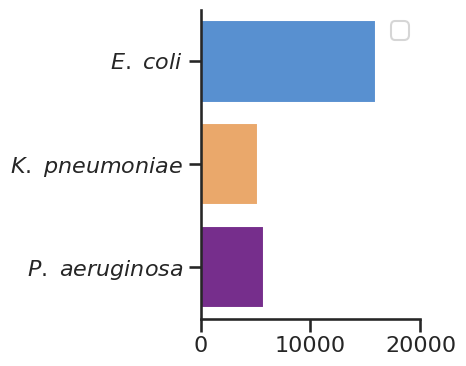

In [12]:
plot_total_species_counts(result_h, where="hospital")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

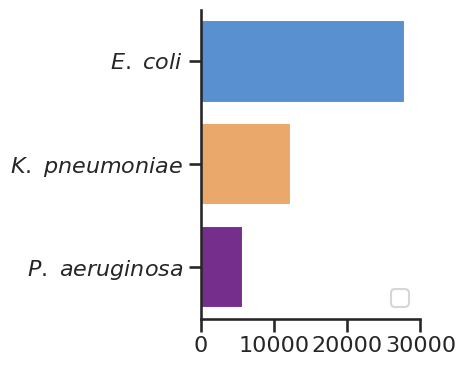

In [13]:
plot_total_species_counts(result, where="all")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

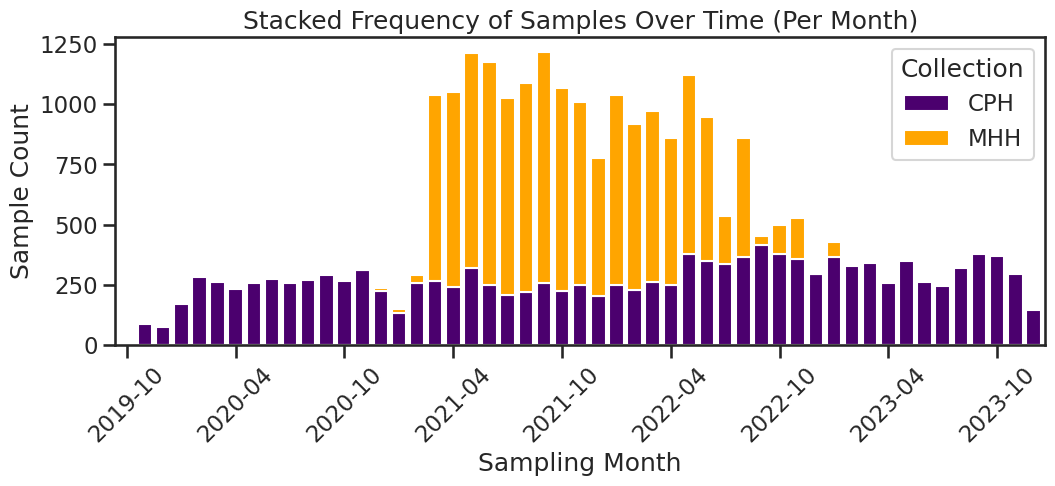

In [14]:
plot_sample_frequency(result_h)

In [15]:
def plot_species_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M').astype(str)
    
    species_order = ["Klebsiella pneumoniae", "Escherichia coli", "Pseudomonas aeruginosa"]
    species_list = [s for s in species_order if s in df['species'].unique()]
    
    fig, axes = plt.subplots(nrows=len(species_list), ncols=1, figsize=(12, 2.5 * len(species_list)), sharex=True)
    colors = {'MHH': '#4b006e', 'CPH': '#4b006e', 'SRA': '#008080'}
    alphas = {'MHH': 1, 'CPH': 0.5, 'SRA': 0.7}  # Define transparency for each collection

    if len(species_list) == 1:
        axes = [axes]

    for ax, species in zip(axes, species_list):
        species_df = df[df['species'] == species]
        sample_counts = species_df.groupby(['year_month', 'collection']).size().unstack(fill_value=0)

        if not sample_counts.empty:
            bars = sample_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8,
                                      color=[colors.get(col, 'gray') for col in sample_counts.columns])

            # Assign alpha values correctly
            for collection, col_bars in zip(sample_counts.columns, bars.containers):
                for bar in col_bars:
                    bar.set_alpha(alphas.get(collection, 1))  # Use alpha dictionary

            ax.set_title(species, fontsize=18)
            ax.set_ylabel("Sample Count", fontsize=18)
            ax.set_xticks(range(0, len(sample_counts.index), 6))
            ax.set_xticklabels(sample_counts.index[::6], rotation=45, fontsize=16)

    plt.xlabel("Sampling Month", fontsize=18)
    plt.legend(facecolor="white")
    
    plt.savefig(f'../../out/figures/sample_counts_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/sample_counts_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')
    
    plt.show();

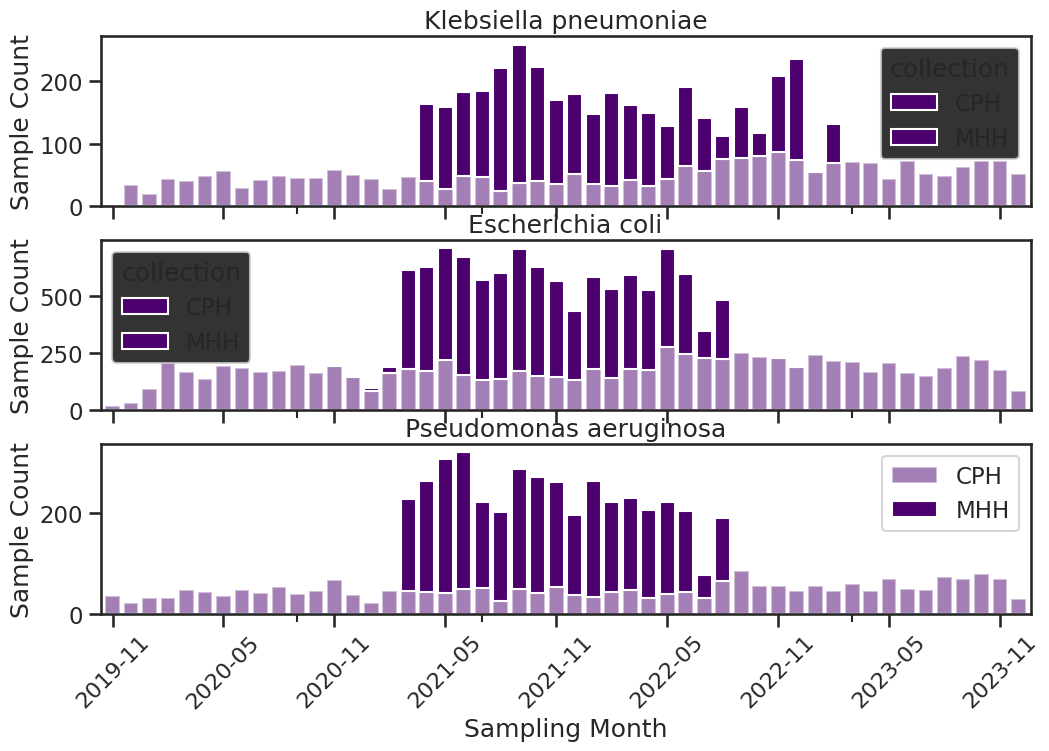

In [275]:
plot_species_frequency(result_h)

In [29]:
def plot_species_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M').astype(str)

    species_order = [
        "Klebsiella pneumoniae",
        "Escherichia coli",
        "Pseudomonas aeruginosa"
    ]
    species_list = [s for s in species_order if s in df['species'].unique()]

    color_map = {
        "Escherichia coli": "#448ee4",            # blue
        "Klebsiella pneumoniae": "#ffa756",       # orange
        "Pseudomonas aeruginosa": "#7e1e9c"       # purple
    }

    alphas = {
        'MHH': 1,
        'CPH': 0.5,
        'SRA': 0.7
    }

    fig, axes = plt.subplots(
        nrows=len(species_list),
        ncols=1,
        figsize=(9, 3 * len(species_list)),
        sharex=True
    )

    if len(species_list) == 1:
        axes = [axes]

    for ax, species in zip(axes, species_list):
        sp = df[df['species'] == species]

        # counts per month per collection
        counts = sp.groupby(['year_month', 'collection']).size().unstack(fill_value=0)

        # total line (black)
        total_counts = counts.sum(axis=1)
        ax.plot(
            total_counts.index, total_counts.values,
            color="grey", linewidth=3, label="Total", alpha=1
        )

        # one colored line per collection (same species color, varying alpha)
        for collection in counts.columns:
            ax.plot(
                counts.index, counts[collection].values,
                color=color_map[species],
                alpha=alphas.get(collection, 1),
                linewidth=3,
                label=f"{collection}"
            )

        ax.set_title(f"$\\it{{{species}}}$", fontsize=18)
        ax.set_ylabel("Sample Count", fontsize=16)
        ax.set_xticks(range(0, len(counts.index), 6))
        ax.set_xticklabels(counts.index[::6], rotation=45, fontsize=16)

    plt.xlabel("Sampling Month", fontsize=18)
    plt.legend(facecolor="white")

    plt.savefig('../../out/figures/sample_counts_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig('../../out/figures/sample_counts_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True)

    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

<Figure size 900x0 with 0 Axes>

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

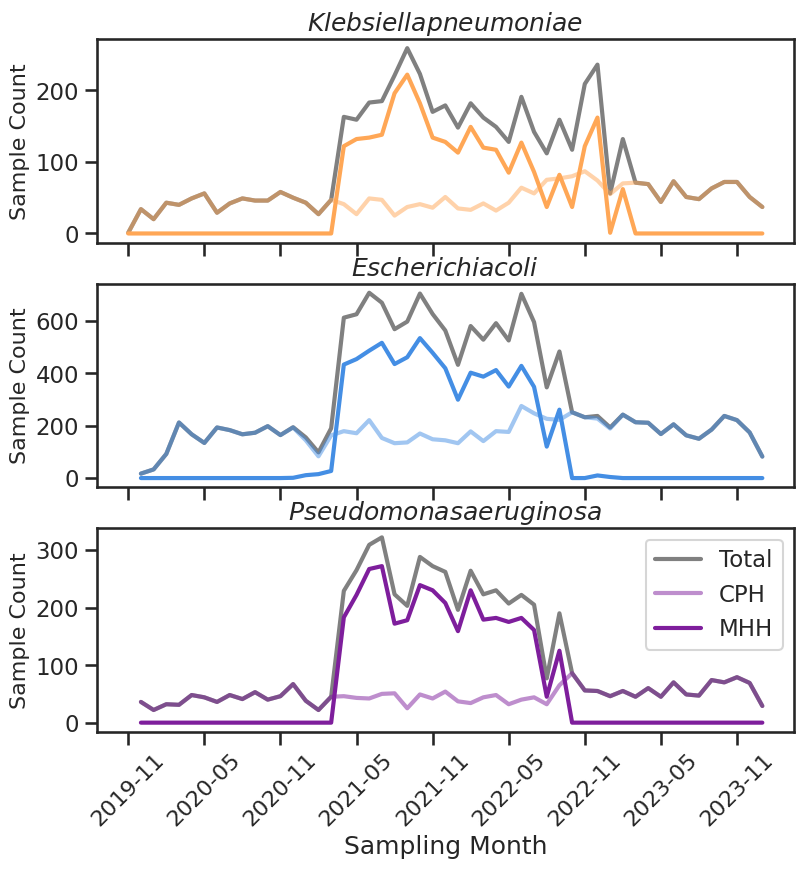

In [30]:
plot_species_frequency(result_h)

In [306]:
def plot_patients_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M').astype(str)
    
    species_order = ["Klebsiella pneumoniae", "Escherichia coli", "Pseudomonas aeruginosa"]
    species_list = [s for s in species_order if s in df['species'].unique()]
    
    fig, axes = plt.subplots(nrows=len(species_list), ncols=1, figsize=(12, 2.5 * len(species_list)), sharex=True)
    colors = {'MHH': '#8c000f', 'CPH': '#8c000f', 'SRA': '#008080'}
    alphas = {'MHH': 1, 'CPH': 0.5, 'SRA': 0.7}  # Define transparency for each collection

    if len(species_list) == 1:
        axes = [axes]

    for ax, species in zip(axes, species_list):
        species_df = df[df['species'] == species]
        unique_pat_counts = species_df.groupby(['year_month', 'collection'])['pat_id'].nunique().unstack(fill_value=0)

        if not unique_pat_counts.empty:
            bars = unique_pat_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8,
                                          color=[colors.get(col, 'gray') for col in unique_pat_counts.columns])

            # Assign alpha values correctly
            for collection, col_bars in zip(unique_pat_counts.columns, bars.containers):
                for bar in col_bars:
                    bar.set_alpha(alphas.get(collection, 1))  # Use alpha dictionary

            ax.set_title(species, fontsize=18)
            ax.set_ylabel("Unique Patient Count", fontsize=18)
            ax.set_xticks(range(0, len(unique_pat_counts.index), 6))
            ax.set_xticklabels(unique_pat_counts.index[::6], rotation=45, fontsize=16)

    plt.xlabel("Sampling Month", fontsize=18)
    plt.legend(facecolor="white")
    
    plt.savefig(f'../../out/figures/patient_counts_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/patient_counts_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')
    
    plt.show();

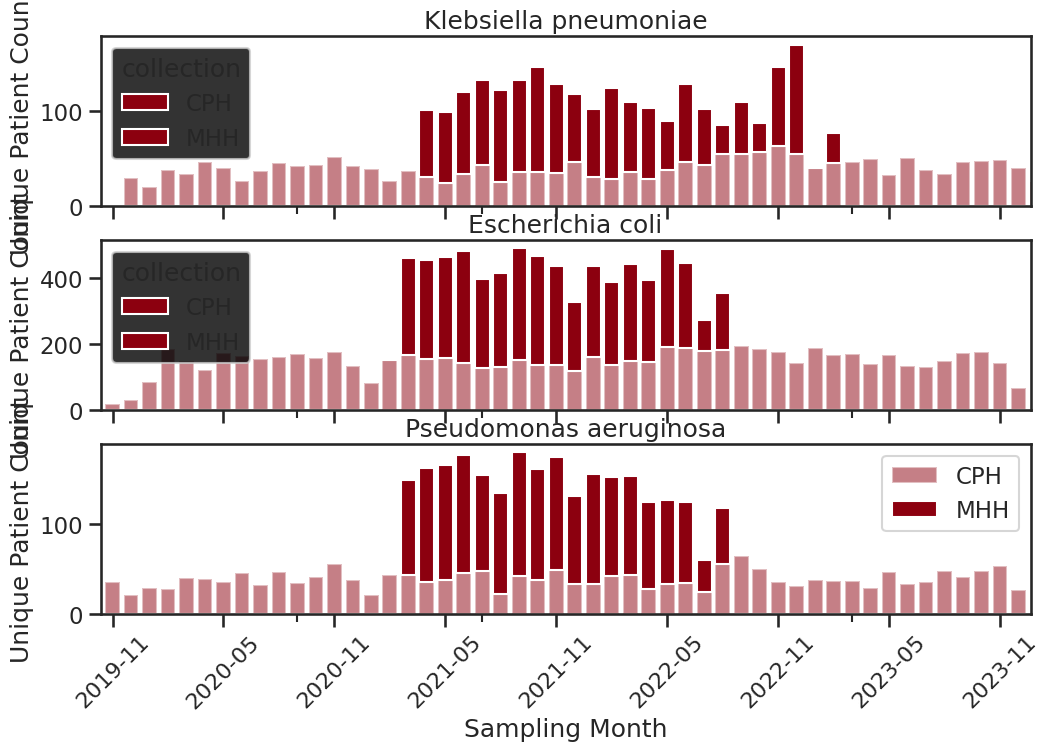

In [307]:
plot_patients_frequency(result_h)

In [299]:
def plot_sex_distribution(df):
    df = df[df['sex'].notna()]
    sex_counts = df.groupby(['collection', 'sex']).size().unstack(fill_value=0)
    sex_counts['female_percentage'] = (sex_counts.get('F', 0) / sex_counts.sum(axis=1)) * 100
    print(sex_counts)

    # Define colors and alpha values
    colors = {'MHH': 'xkcd:blue green', 'CPH': 'xkcd:blue green'}
    alphas = {'MHH': 1, 'CPH': 0.5}

    # Ensure the order is MHH first, then CPH
    ordered_collections = ['MHH', 'CPH']
    sex_counts = sex_counts.reindex(ordered_collections)

    fig, ax = plt.subplots(figsize=(2, 3))
    bars = sex_counts['female_percentage'].plot(kind='bar', 
                                                color=[colors.get(c, 'gray') for c in sex_counts.index], 
                                                ax=ax, width=0.6)

    # Apply alpha per collection
    for bar, c in zip(bars.patches, sex_counts.index):
        bar.set_alpha(alphas.get(c, 1))  # Default to 1 if collection not in dictionary

    ax.set_ylabel('Female %', fontsize=16)
    ax.set_xlabel('Collection', fontsize=16)
    ax.set_title('Sex Distribution', fontsize=16)
    ax.set_xticklabels(sex_counts.index, rotation=45)
    
    plt.savefig(f'../../out/figures/sex_distribution_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/sex_distribution_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')

    plt.show();

sex            F     M  female_percentage
collection                               
CPH         5133  4249          54.711149
MHH         5879  6058          49.250230


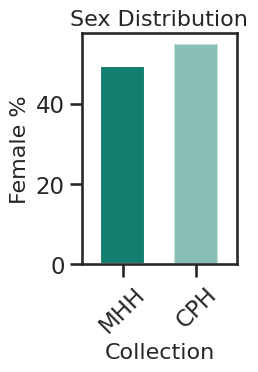

In [300]:
plot_sex_distribution(result_h)

In [41]:
def plot_sex_distribution(df):
    # Filter out rows where sex is missing
    df = df[df['sex'].notna()]

    # Define species order
    species_order = ["Klebsiella pneumoniae", "Escherichia coli", "Pseudomonas aeruginosa"]

    # Define color map
    color_map = {
        "Escherichia coli": "#448ee4",            # blue
        "Klebsiella pneumoniae": "#ffa756",       # orange
        "Pseudomonas aeruginosa": "#7e1e9c"       # purple
    }

    # Prepare a figure with subplots (3 rows, 1 column)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(3, 9), sharex=True)
    
    # Loop over the species to create a plot for each species
    for ax, species in zip(axes, species_order):
        species_df = df[df['species'] == species]

        # Count the sex distribution per collection type
        sex_counts = species_df.groupby(['collection', 'sex']).size().unstack(fill_value=0)
        
        # Calculate the total female count and total count per species
        total_female_count = sex_counts.get('F', 0).sum()
        total_count = sex_counts.sum(axis=1).sum()

        # Calculate the female percentage per collection
        sex_counts['female_percentage'] = (sex_counts.get('F', 0) / sex_counts.sum(axis=1)) * 100

        # Calculate the overall female percentage for the species across all collections
        species_female_percentage = (total_female_count / total_count) * 100
        
        # Define the ordered collection types (MHH, CPH)
        ordered_collections = ['MHH', 'CPH']
        sex_counts = sex_counts.reindex(ordered_collections)

        # Plot the female percentage as a bar plot
        bars = sex_counts['female_percentage'].plot(kind='bar', 
                                                     color=[color_map.get(species, 'gray') for _ in sex_counts.index], 
                                                     ax=ax, width=0.6)

        # Apply alpha per collection type
        for bar, c in zip(bars.patches, sex_counts.index):
            bar.set_alpha(1 if c == 'MHH' else 0.5)  # Alpha 1 for MHH, 0.5 for CPH

        # Set titles, labels, and format axes
        ax.set_ylabel('Female %', fontsize=16)
        ax.set_xlabel('Collection', fontsize=16)
        ax.set_xticklabels(sex_counts.index, rotation=45, fontsize=14)

        # Set y-axis limits for all plots (from 0 to 60)
        ax.set_ylim(0, 65)

    # Adjust layout
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'../../out/figures/sex_distribution_species.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/sex_distribution_species.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')

    # Show the plot
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

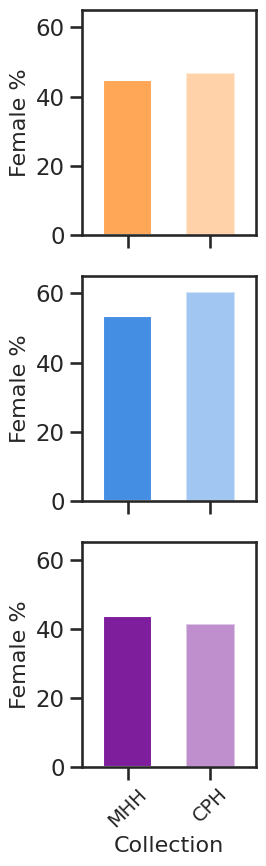

In [42]:
plot_sex_distribution(result_h)

In [278]:
def plot_age_distribution(df):
    df = df[df['age_bin'].notna()]

    # Count occurrences of each age bin as proportions
    age_counts = df['age_bin'].value_counts(normalize=True).sort_index()

    # Ensure correct bin order by sorting numerically
    sorted_bins = sorted(age_counts.index, key=lambda x: int(x.split(',')[0][1:]))

    # Plot
    fig, ax = plt.subplots(figsize=(6, 2))
    sns.barplot(x=sorted_bins, y=age_counts[sorted_bins], color='xkcd:lightish blue', ax=ax)

    ax.set_ylabel('Proportion', fontsize=18)
    ax.set_xlabel('', fontsize=16)
    ax.set_title('Age Distribution', fontsize=16)
    ax.set_xticklabels(sorted_bins, rotation=45)
    
    plt.savefig(f'../../out/figures/age_distribution_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/age_distribution_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')

    plt.show()

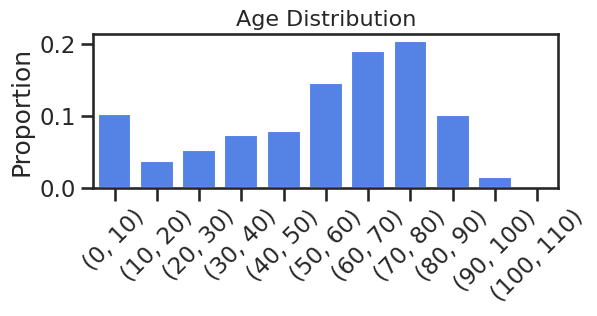

In [279]:
plot_age_distribution(result_h)

In [280]:
def plot_age_distribution_coll(df):
    df = df[df['age_bin'].notna()]

    age_counts_MHH = df[df['collection'] == 'MHH']['age_bin'].value_counts(normalize=True)
    age_counts_CPH = df[df['collection'] == 'CPH']['age_bin'].value_counts(normalize=True)

    sorted_bins = sorted(set(age_counts_MHH.index).union(set(age_counts_CPH.index)), 
                         key=lambda x: int(x.split(',')[0][1:]))

    age_counts_MHH = age_counts_MHH.reindex(sorted_bins, fill_value=0)
    age_counts_CPH = age_counts_CPH.reindex(sorted_bins, fill_value=0)

    fig, ax = plt.subplots(figsize=(6, 3))

    sns.barplot(x=sorted_bins, y=age_counts_MHH, color="xkcd:bright blue", ax=ax, 
                label="MHH", alpha=1)
    sns.barplot(x=sorted_bins, y=-age_counts_CPH, color="xkcd:bright blue", ax=ax, 
                label="CPH", alpha=0.5)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel('Proportion', fontsize=18)
    ax.set_xlabel('', fontsize=16)
    ax.set_title("Age Distribution", fontsize=18)
    ax.set_xticklabels(sorted_bins, rotation=45)
    ax.legend(facecolor="white", loc="lower left")
    ax.set_ylim(-0.28, 0.28)
    
    plt.savefig(f'../../out/figures/age_distribution_hospital.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/age_distribution_hospital.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')

    plt.show();

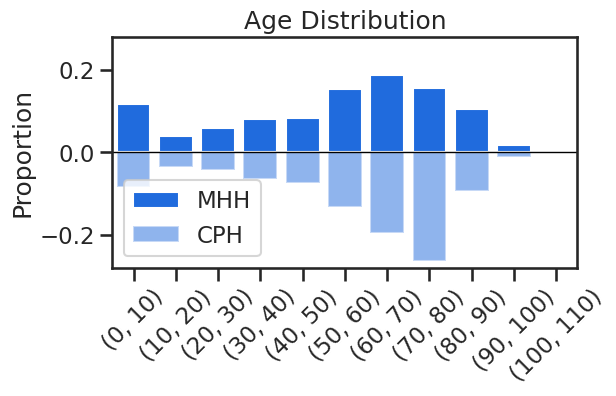

In [281]:
plot_age_distribution_coll(result_h)

In [49]:
def plot_age_distribution_coll(df):
    # Filter out rows where age_bin is missing
    df = df[df['age_bin'].notna()]

    # Define species order
    species_order = ["Klebsiella pneumoniae", "Escherichia coli", "Pseudomonas aeruginosa"]

    # Define color map for species
    color_map = {
        "Escherichia coli": "#448ee4",            # blue
        "Klebsiella pneumoniae": "#ffa756",       # orange
        "Pseudomonas aeruginosa": "#7e1e9c"       # purple
    }

    # Prepare the figure with 3 subplots (one for each species)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(4, 9), sharex=True)

    # Loop over the species to create a plot for each species
    for ax, species in zip(axes, species_order):
        species_df = df[df['species'] == species]

        # Get the normalized age distribution for MHH and CPH
        age_counts_MHH = species_df[species_df['collection'] == 'MHH']['age_bin'].value_counts(normalize=True)
        age_counts_CPH = species_df[species_df['collection'] == 'CPH']['age_bin'].value_counts(normalize=True)

        # Sort the age bins
        sorted_bins = sorted(set(age_counts_MHH.index).union(set(age_counts_CPH.index)), 
                             key=lambda x: int(x.split(',')[0][1:]))

        # Reindex to ensure all bins are represented (fill missing values with 0)
        age_counts_MHH = age_counts_MHH.reindex(sorted_bins, fill_value=0)
        age_counts_CPH = age_counts_CPH.reindex(sorted_bins, fill_value=0)

        # Plot the age distributions for MHH and CPH
        sns.barplot(x=sorted_bins, y=age_counts_MHH, color=color_map[species], ax=ax, 
                    label="MHH", alpha=1)  # MHH bars in full color
        sns.barplot(x=sorted_bins, y=-age_counts_CPH, color=color_map[species], ax=ax, 
                    label="CPH", alpha=0.5)  # CPH bars in same color but with transparency

        # Add horizontal line at 0
        ax.axhline(0, color='black', linewidth=1)

        # Set axis labels and titles
        ax.set_ylabel('Proportion', fontsize=16)
        ax.set_xlabel('', fontsize=16)
        ax.set_xticklabels(sorted_bins, rotation=45, fontsize=14)

        # Set y-axis limit
        ax.set_ylim(-0.3, 0.3)

        # Add a legend
        ax.legend(facecolor="white", loc="lower left")

    # Adjust layout for subplots
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'../../out/figures/age_distribution_species.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../../out/figures/age_distribution_species.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')

    # Show the plot
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

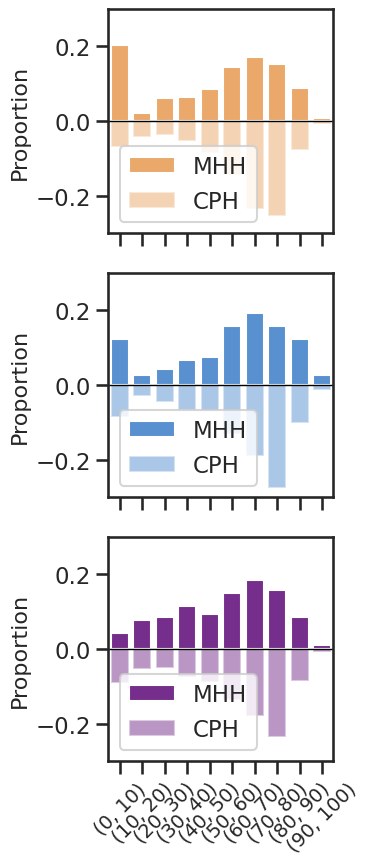

In [50]:
plot_age_distribution_coll(result_h)

In [321]:
def plot_bsi_frequency(df):
    df['samplingdate'] = pd.to_datetime(df['samplingdate'], errors='coerce')
    df['year_month'] = df['samplingdate'].dt.to_period('M').astype(str)
    
    df_bsi = df[df['infection_type'] == "BSI"]
    species_order = ["Klebsiella pneumoniae", "Escherichia coli", "Pseudomonas aeruginosa"]
    species_list = [s for s in species_order if s in df_bsi['species'].unique()]
    
    fig, axes = plt.subplots(nrows=len(species_list), ncols=1, figsize=(12, 2.5 * len(species_list)), sharex=True)
    colors = {'MHH': '#8c000f', 'CPH': '#8c000f', 'SRA': '#008080'}
    alphas = {'MHH': 1, 'CPH': 0.5, 'SRA': 0.7}  

    if len(species_list) == 1:
        axes = [axes]

    for ax, species in zip(axes, species_list):
        species_df = df_bsi[df_bsi['species'] == species]
        unique_pat_counts = species_df.groupby(['year_month', 'collection'])['pat_id'].nunique().unstack(fill_value=0)

        if not unique_pat_counts.empty:
            bars = unique_pat_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8,
                                          color=[colors.get(col, 'gray') for col in unique_pat_counts.columns])

            for collection, col_bars in zip(unique_pat_counts.columns, bars.containers):
                for bar in col_bars:
                    bar.set_alpha(alphas.get(collection, 1))  

            ax.set_title(species, fontsize=18)
            ax.set_ylabel("BSI Count", fontsize=18)
            ax.set_xticks(range(0, len(unique_pat_counts.index), 6))
            ax.set_xticklabels(unique_pat_counts.index[::6], rotation=45, fontsize=16)

    plt.xlabel("Sampling Month", fontsize=18)
    plt.legend(facecolor="white")
    plt.show()

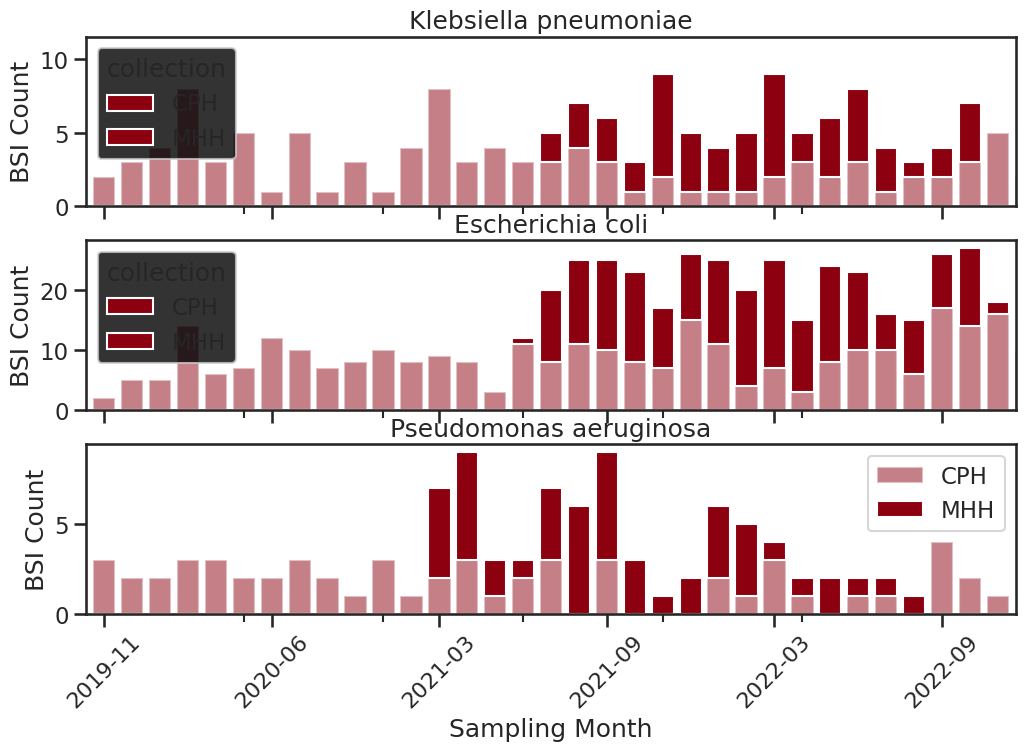

In [322]:
plot_bsi_frequency(result_h)

In [337]:
def plot_monthly_norm_counts_by_top_st(data, samplingdate_col, st_col, pat_id_col, top_n=10, title="", species="", ylim=None):
    """
    Plots a bar plot of monthly normalized counts (counting unique `pat_id`), split by top `ST` values.
    Includes zoom-in from 2019-01-01 and highlights shaded periods.

    Parameters:
        data (pd.DataFrame): The input dataframe containing the data.
        samplingdate_col (str): The name of the column containing the sampling date in 'YYYY-MM-DD' format.
        st_col (str): The name of the column containing the sequence type (ST).
        pat_id_col (str): The name of the column containing patient identifiers.
        top_n (int): The number of top `ST` values to include in the plot.
        title (str): The title of the plot.
        species (str): A species name for filename generation.
        ylim (tuple): Y-axis limits for the plot.

    Returns:
        None: Displays the plot.
    """
    periods = [
        ('Pre-pandemic', '2015-01-01', '2020-03-01', 'white'),
        ('Pandemic acute', '2020-03-01', '2021-06-01', '#ffb07c'),
        ('Pandemic transition', '2021-07-01', '2022-07-01', '#e2ca76'),
        ('Post-pandemic', '2022-06-01', '2024-01-01', 'white')
    ]

    # Exclude rows with ST == '-'
    data = data[data[st_col] != '-']

    # Treat NaN values in `pat_id_col` as unique identifiers
    data[pat_id_col] = data[pat_id_col].fillna(data.index.to_series().astype(str) + '_NaN')

    # Keep only the first occurrence of each `pat_id`
    data = data.drop_duplicates(subset=[pat_id_col])

    # Convert sampling dates to datetime and filter for zoom-in range
    data[samplingdate_col] = pd.to_datetime(data[samplingdate_col])
    data = data[(data[samplingdate_col] >= '2019-01-01') & (data[samplingdate_col] <= '2023-12-31')]
    data['month'] = data[samplingdate_col].dt.to_period('M')

    # Determine top `ST` values by count
    top_st = (data[st_col]
              .value_counts()
              .nlargest(top_n)
              .index)
    data = data[data[st_col].isin(top_st)]

    # Create a complete range of months from 2019-01 to 2023-12
    full_month_range = pd.period_range('2019-01', '2023-12', freq='M')

    # Create a dataframe with all combinations of months and top ST
    complete_index = pd.MultiIndex.from_product([full_month_range, top_st], names=['month', st_col])
    monthly_counts = (data.groupby(['month', st_col])
                         .size()
                         .reindex(complete_index, fill_value=0)
                         .reset_index(name='Counts'))
    monthly_counts['month'] = monthly_counts['month'].astype(str)  # Convert Period to string for plotting

    # Pivot data for plotting
    pivot_table = monthly_counts.pivot(index='month', columns=st_col, values='Counts').fillna(0)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(24, 6))
    
    # Plot stacked bars
    pivot_table.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=1)

    # Add shaded areas for periods
    for label, start, end, color in periods:
        start_date = pd.Timestamp(start)
        end_date = pd.Timestamp(end)
        if end_date >= pd.Timestamp('2019-01-01'):  # Ensure it's within the specified range
            start_str = str(start_date.to_period('M'))
            end_str = str(end_date.to_period('M'))

            start_idx = pivot_table.index.get_loc(start_str) if start_str in pivot_table.index else None
            end_idx = pivot_table.index.get_loc(end_str) if end_str in pivot_table.index else None

            if start_idx is not None and end_idx is not None:
                ax.axvspan(start_idx - 0.5, end_idx + 0.5, color=color, alpha=0.3, label=label if color != 'white' else None)

    # Format the plot
    ax.set_xlabel('Month', fontsize=18)
    ax.set_ylabel('Normalized counts', fontsize=18)
    ax.set_title(title)
    tick_positions = list(range(0, len(pivot_table.index), 5))
    tick_labels = [pivot_table.index[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=18)
    if ylim:
        ax.set_ylim(ylim)
        
    # Add legend for both collections and periods
    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))
    ax.legend(unique_handles_labels.values(), unique_handles_labels.keys(), title='Legend', facecolor="white", bbox_to_anchor=(1.1, 1))

    plt.tight_layout()

    filename_base = f"../../out/figures/monthly_normalized_ST_top{top_n}_{species}"
    plt.savefig(f"{filename_base}.png", dpi=75, bbox_inches='tight', transparent=True)
    plt.savefig(f"{filename_base}.svg", dpi=75, bbox_inches='tight', transparent=True)

    plt.show()

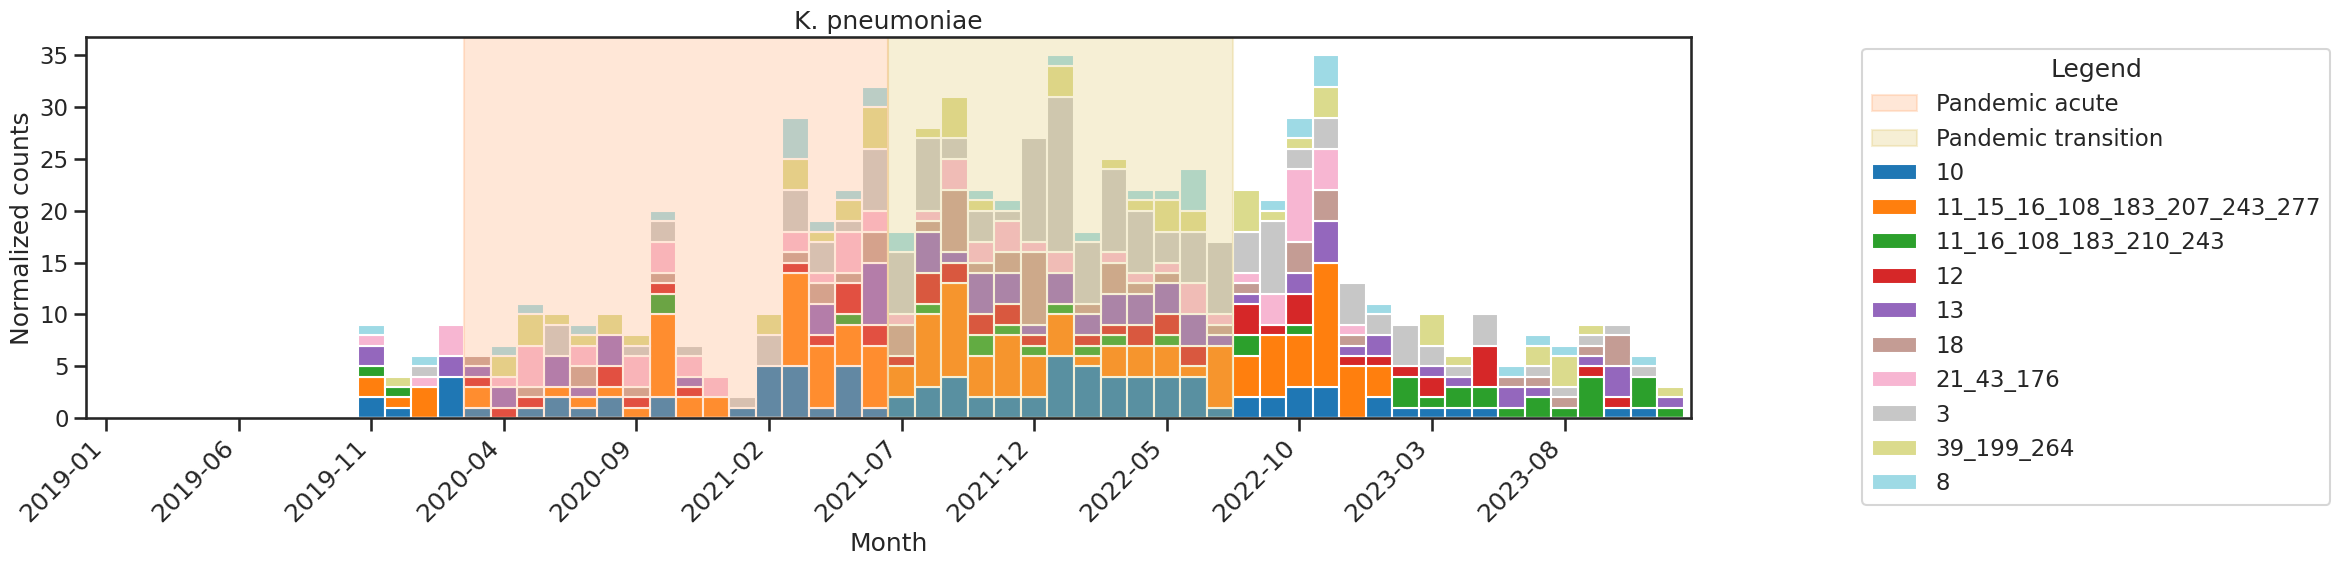

In [342]:
plot_monthly_norm_counts_by_top_st(data=kp_h,
                                  samplingdate_col="samplingdate",
                                  st_col="SC",
                                  pat_id_col="pat_id",
                                  top_n=10,
                                  title="K. pneumoniae",
                                  species="kp")

In [347]:
def plot_monthly_proportion_by_top_st(data, samplingdate_col, st_col, pat_id_col, top_n=10, title="", species="", ylim=None):
    periods = [
        ('Pre-pandemic', '2015-01-01', '2020-03-01', 'white'),
        ('Pandemic acute', '2020-03-01', '2021-06-01', '#ffb07c'),
        ('Pandemic transition', '2021-07-01', '2022-07-01', '#e2ca76'),
        ('Post-pandemic', '2022-06-01', '2024-01-01', 'white')
    ]

    data = data[data[st_col] != '-']
    data[pat_id_col] = data[pat_id_col].fillna(data.index.to_series().astype(str) + '_NaN')
    data = data.drop_duplicates(subset=[pat_id_col])
    data[samplingdate_col] = pd.to_datetime(data[samplingdate_col])
    data['month'] = data[samplingdate_col].dt.to_period('M')

    top_st = (data[st_col].value_counts().nlargest(top_n).index)
    data = data[data[st_col].isin(top_st)]
    
    min_month = data['month'].min()
    max_month = data['month'].max()
    full_month_range = pd.period_range(min_month, max_month, freq='M')
    complete_index = pd.MultiIndex.from_product([full_month_range, top_st], names=['month', st_col])
    
    monthly_counts = (data.groupby(['month', st_col]).size()
                      .reindex(complete_index, fill_value=0)
                      .reset_index(name='Counts'))
    
    monthly_totals = monthly_counts.groupby('month')['Counts'].transform('sum')
    monthly_counts['Proportion'] = monthly_counts['Counts'] / monthly_totals
    monthly_counts['month'] = monthly_counts['month'].astype(str)
    
    pivot_table = monthly_counts.pivot(index='month', columns=st_col, values='Proportion').fillna(0)

    fig, ax = plt.subplots(figsize=(20, 8))
    x = np.arange(len(pivot_table.index))
    y = pivot_table.values.T
    
    ax.stackplot(x, y, labels=top_st, alpha=0.8)
    
    for label, start, end, color in periods:
        start_date, end_date = pd.Timestamp(start), pd.Timestamp(end)
        if start_date >= min_month.start_time and end_date <= max_month.end_time:
            start_str, end_str = str(start_date.to_period('M')), str(end_date.to_period('M'))
            start_idx = pivot_table.index.get_loc(start_str) if start_str in pivot_table.index else None
            end_idx = pivot_table.index.get_loc(end_str) if end_str in pivot_table.index else None
            if start_idx is not None and end_idx is not None:
                ax.axvspan(start_idx - 0.5, end_idx + 0.5, color=color, alpha=0.3, label=label if color != 'white' else None)
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Proportion')
    ax.set_title(title)
    ax.set_xticks(range(0, len(pivot_table.index), 5))
    ax.set_xticklabels(pivot_table.index[::5], rotation=45, ha='right')
    if ylim:
        ax.set_ylim(ylim)
    
    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))
    ax.legend(unique_handles_labels.values(), unique_handles_labels.keys(), title='Legend', facecolor="white", bbox_to_anchor=(1.1, 1))
    
    plt.tight_layout()
    
    filename_base = f"../../out/figures/monthly_proportion_ST_top{top_n}_{species}"
    plt.savefig(f"{filename_base}.png", dpi=75, bbox_inches='tight', transparent=True)
    plt.savefig(f"{filename_base}.svg", dpi=75, bbox_inches='tight', transparent=True)
    
    plt.show()

<ipython-input-347-147a602a7a3b>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[pat_id_col] = data[pat_id_col].fillna(data.index.to_series().astype(str) + '_NaN')


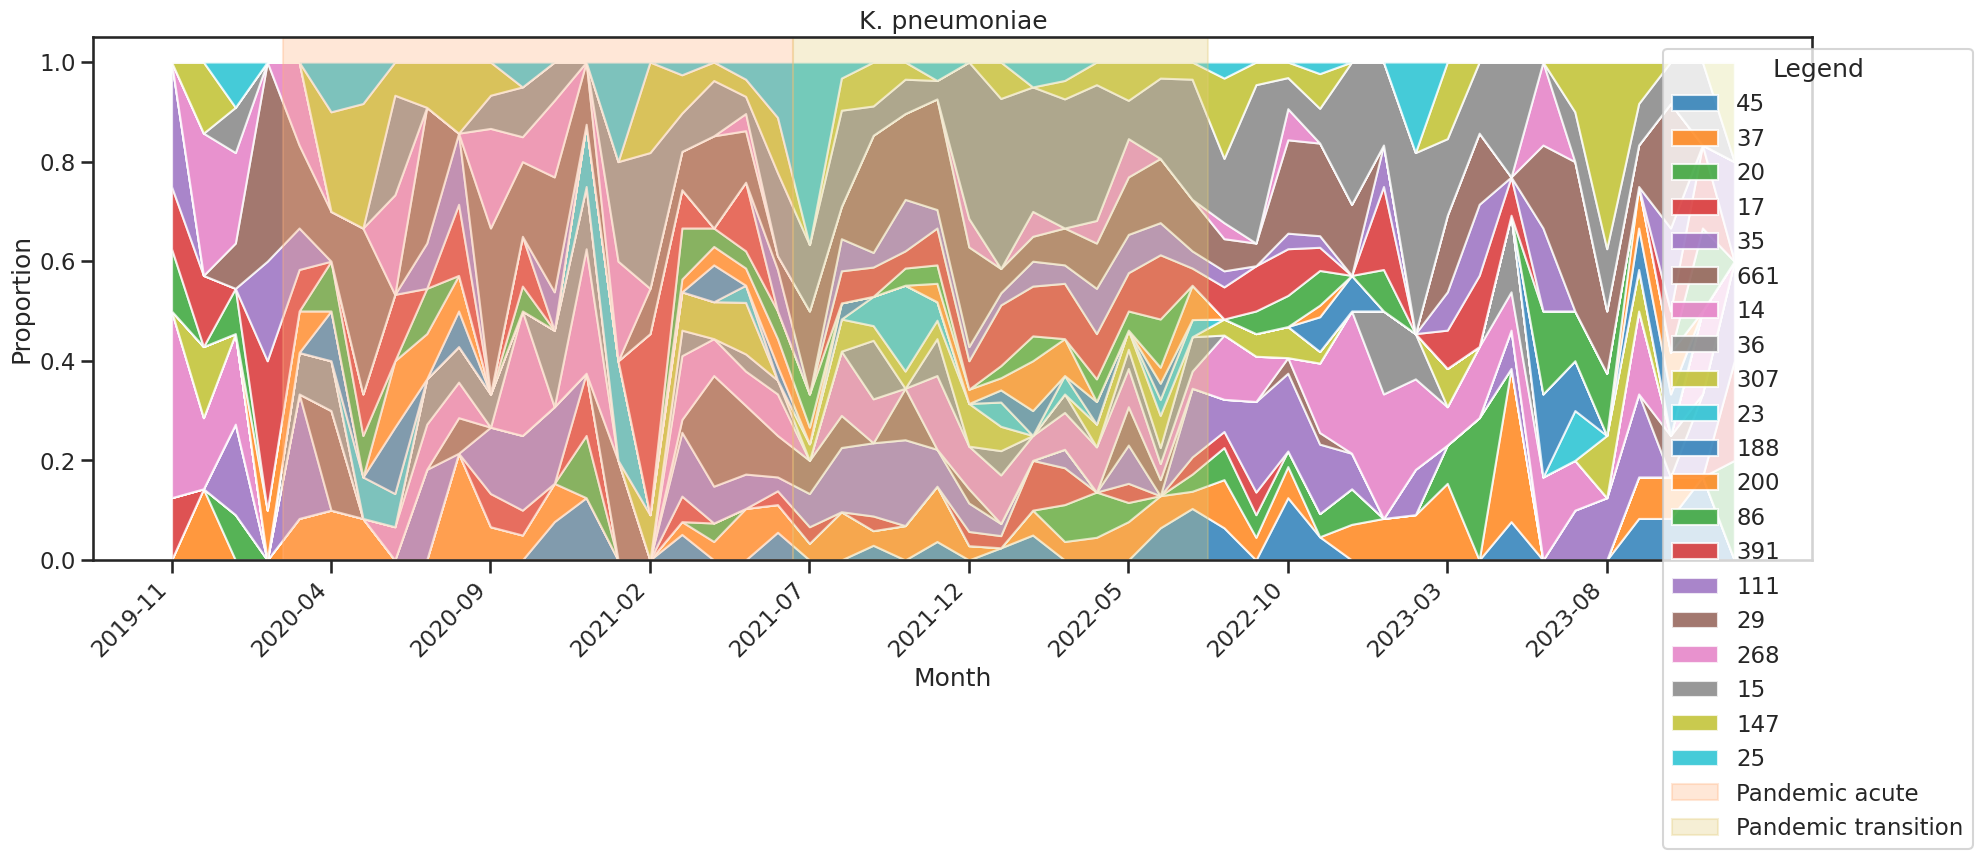

In [348]:
plot_monthly_proportion_by_top_st(data=kp_h,
                                  samplingdate_col="samplingdate",
                                  st_col="ST",
                                  pat_id_col="pat_id",
                                  top_n=20,
                                  title="K. pneumoniae",
                                  species="kp")

In [285]:
result_h.loc[result_h["collection"] == "MHH", "samplingdate"].min()

Timestamp('2020-11-26 00:00:00')

In [286]:
result_h.loc[result_h["collection"] == "MHH", "samplingdate"].max()

Timestamp('2023-01-18 00:00:00')

In [284]:
result_h["samplingdate"].max()

Timestamp('2023-12-29 00:00:00')

In [289]:
kp.shape

(12282, 23)

In [295]:
kp_h["pat_id"].nunique()

2861

In [30]:
ec.shape

(27946, 19)

In [296]:
ec_h["pat_id"].nunique()

10077

In [31]:
pa.shape

(8401, 20)

In [294]:
pa_h["pat_id"].nunique()

2862